# Steering Vector Validation

This notebook documents how we validate the **political-compass steering vectors** that
underpin the project — the economic and social directions extracted from `Mistral-7B-v0.1`
(layers 8, 12, 16, 20, 24) by contrastive activation addition.

The steering vectors are the foundation of the whole MoCE pipeline: if they do not
faithfully encode the two political axes, every downstream routing and debiasing result
is built on sand. We therefore validate them with a **three-tier plan**:

| Tier | Question | Cost | Status |
|---|---|---|---|
| **1 — Geometry** | Are the axes independent, non-artifactual, and generalizing? | CPU, seconds | **done (this notebook)** |
| **2 — External** | Do projections agree with measured ideology (DW-NOMINATE, MARPOR)? | CPU/GPU | planned |
| **3 — Robustness** | Negation flips, paraphrase invariance, cross-topic generalization? | mixed | planned |

Everything below is **Tier 1**. The computations are re-run live from
`src/13_steering_vector_geometry.py`; the JSON summary lives at
`data/steering-vectors/reports/tier1_geometry_report.json`.

## Setup

We load the Tier 1 module directly from `src/` (its filename starts with a digit, so it
is imported via `importlib` rather than a normal `import`). All metrics are then computed
from the same two artifacts the pipeline produces:

- `data/steering-vectors/vectors/{axis}_vectors.pt` — the per-layer and aggregate directions
- `data/steering-vectors/activations/{axis}_activations.pt` — pooled activations for the 90 contrastive pairs per axis

In [1]:
import importlib.util
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# resolve the repo root whether the notebook runs from notebooks/ or the root
REPO = Path.cwd()
if not (REPO / "src").exists():
    REPO = REPO.parent

spec = importlib.util.spec_from_file_location(
    "tier1_geometry", REPO / "src" / "13_steering_vector_geometry.py"
)
tier1 = importlib.util.module_from_spec(spec)
sys.modules["tier1_geometry"] = tier1  # let the module's @dataclass resolve itself
spec.loader.exec_module(tier1)

METHOD = "mean_difference"  # the production extraction method
economic = tier1.load_axis_data("economic", tier1.DEFAULT_VECTORS_DIR,
                                 tier1.DEFAULT_ACTIVATIONS_DIR, METHOD)
social = tier1.load_axis_data("social", tier1.DEFAULT_VECTORS_DIR,
                              tier1.DEFAULT_ACTIVATIONS_DIR, METHOD)

n_pairs = next(iter(economic.pos_acts.values())).shape[0]
print(f"layers          : {economic.layers}")
print(f"contrastive pairs: {n_pairs} per axis")
print(f"hidden dimension : {economic.final_vector.shape[0]}")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

layers          : [8, 12, 16, 20, 24]
contrastive pairs: 90 per axis
hidden dimension : 4096


## Tier 1 — Geometry Checks

Five checks, all derived purely from the stored vectors and activations (no GPU, no new
inference). They answer, in order:

1. **Orthogonality** — are the two axes independent, or is the "2D compass" secretly 1D?
2. **Cross-projection** — does each axis respond only to its own statements?
3. **Null baselines** — is the signal real, or reachable by a random / label-shuffled direction?
4. **Held-out separability** — does the direction generalize to pairs it was not built on?
5. **Method agreement** — do the two extraction methods recover the same direction?

### Test 1 — Axis Orthogonality

A political *compass* needs two genuinely separate axes. If the economic and social
steering vectors were strongly correlated, the model would really have one ideological
direction and the "compass" would be a relabelled line.

We measure `cos(economic, social)` for the aggregate vectors and for each layer's vectors.
A value near **0** means independent axes; a large magnitude means they collapse toward 1D.

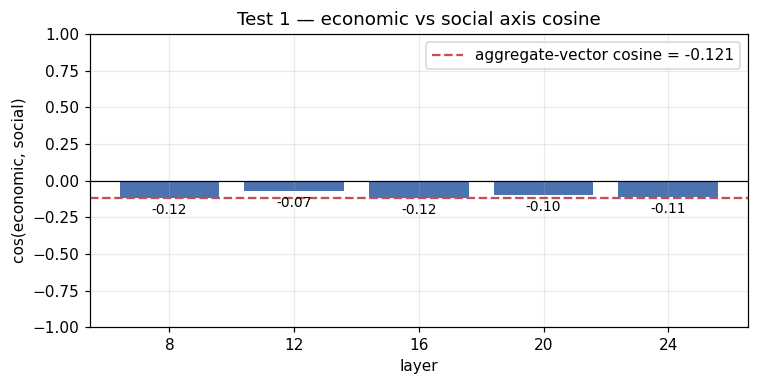

shared variance (cos^2) = 1.5%


In [2]:
ortho = tier1.check_orthogonality(economic, social)
per_layer = [ortho["per_layer_cosine"][l] for l in economic.layers]

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar([str(l) for l in economic.layers], per_layer, color="#4C72B0")
ax.axhline(ortho["final_vector_cosine"], color="#C44E52", ls="--",
           label=f"aggregate-vector cosine = {ortho['final_vector_cosine']:+.3f}")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylim(-1, 1)
ax.set_xlabel("layer")
ax.set_ylabel("cos(economic, social)")
ax.set_title("Test 1 — economic vs social axis cosine")
ax.legend()
for b, v in zip(bars, per_layer):
    ax.text(b.get_x() + b.get_width() / 2, v + (0.06 if v >= 0 else -0.11),
            f"{v:+.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"shared variance (cos^2) = {ortho['final_vector_cosine']**2:.1%}")

**Result — Pass.** The aggregate cosine is **−0.12**, and every per-layer cosine sits
within ±0.12. The axes share only ~1.5% of their variance: the compass is genuinely
two-dimensional and the economic and social directions do not collapse onto one another.

### Test 2 — Cross-Projection Matrix

Orthogonality of the *vectors* is necessary but not sufficient — we also want each axis to
**respond only to its own kind of statement**. So we project both sets of contrastive
pairs onto both axes and measure the pole separation (Cohen's *d*).

- **Diagonal** (economic pairs on the economic axis, social pairs on the social axis) —
  should be large.
- **Off-diagonal** (economic pairs on the social axis, and vice versa) — should be near zero
  if the axes do not leak into each other.

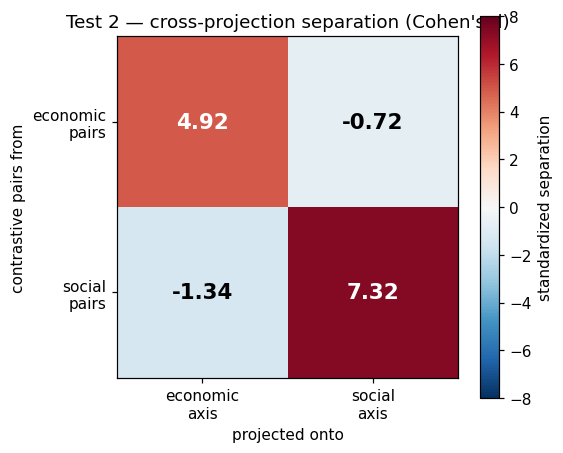

In [3]:
cross = tier1.cross_projection_matrix(economic, social)
names = ["economic", "social"]
M = np.array([[cross["separation_matrix"][s][p] for p in names] for s in names])

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(M, cmap="RdBu_r", vmin=-8, vmax=8)
ax.set_xticks([0, 1], [f"{a}\naxis" for a in names])
ax.set_yticks([0, 1], [f"{a}\npairs" for a in names])
ax.set_xlabel("projected onto")
ax.set_ylabel("contrastive pairs from")
ax.set_title("Test 2 — cross-projection separation (Cohen's d)")
ax.grid(False)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=14,
                fontweight="bold", color="white" if abs(M[i, j]) > 4 else "black")
fig.colorbar(im, label="standardized separation")
plt.tight_layout()
plt.show()

**Result — Pass, with a caveat.** The diagonal (4.92, 7.32) is 5–7× larger than the
off-diagonal (−0.72, −1.34): each axis responds far more strongly to its own statements.

The caveat: the off-diagonal is **not** zero. Social pairs produce a Cohen's *d* of −1.34
on the economic axis — a large effect in absolute terms. The negative signs are
ideologically plausible (authoritarian ↔ economic-left and economic-right ↔ libertarian
do correlate in the real world), so this is probably *partly genuine* rather than pure
contamination. We flag it as **axis leakage to revisit in Tier 3**.

### Test 3 — Null Baselines

A separation of *d* = 5 sounds large — but is it? With 4096 dimensions and only 90 pairs,
even a meaningless direction can overfit and show separation. So we compare the real
separation against two nulls:

- **Random-direction null** — project onto random unit vectors, keep the true labels.
  Shows the separation an *arbitrary* direction achieves.
- **Shuffled-label null** — re-partition the pooled activations into two balanced groups,
  rebuild the direction, re-measure. A permutation test for the pos/neg signal itself.

The real separation must sit far in the right tail of *both*.

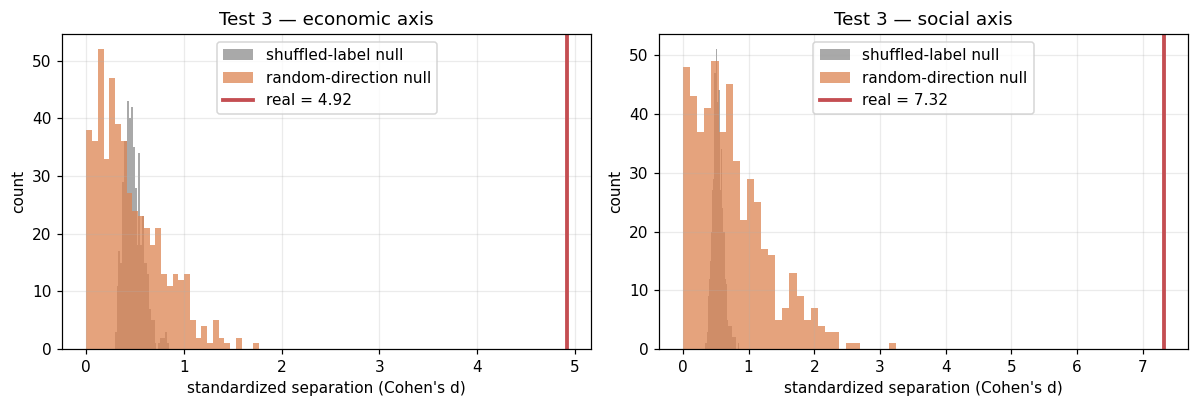

In [4]:
def null_distributions(axis, num_random=500, num_perm=500, seed=0):
    """Recompute the raw random-direction and shuffled-label separation distributions."""
    rng = np.random.default_rng(seed)
    tgen = torch.Generator().manual_seed(seed)
    pos = tier1.combined_projection(axis.pos_acts, axis.layer_vectors, axis.weights)
    neg = tier1.combined_projection(axis.neg_acts, axis.layer_vectors, axis.weights)
    real = tier1.standardized_separation(pos, neg)
    hidden = next(iter(axis.layer_vectors.values())).shape[0]

    random_sep = []
    for _ in range(num_random):
        rv = {l: tier1.unit(torch.randn(hidden, generator=tgen)) for l in axis.layers}
        random_sep.append(abs(tier1.standardized_separation(
            tier1.combined_projection(axis.pos_acts, rv, axis.weights),
            tier1.combined_projection(axis.neg_acts, rv, axis.weights))))

    shuffled_sep = []
    for _ in range(num_perm):
        ga, gb = tier1.pooled_label_permutation(axis.pos_acts, axis.neg_acts, rng)
        pv = tier1.mean_difference_vectors(ga, gb)
        shuffled_sep.append(tier1.standardized_separation(
            tier1.combined_projection(ga, pv, axis.weights),
            tier1.combined_projection(gb, pv, axis.weights)))
    return real, np.array(random_sep), np.array(shuffled_sep)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, axis in zip(axs, [economic, social]):
    real, random_sep, shuffled_sep = null_distributions(axis)
    ax.hist(shuffled_sep, bins=30, alpha=0.75, color="#8C8C8C", label="shuffled-label null")
    ax.hist(random_sep, bins=30, alpha=0.75, color="#DD8452", label="random-direction null")
    ax.axvline(real, color="#C44E52", lw=2.5, label=f"real = {real:.2f}")
    ax.set_title(f"Test 3 — {axis.name} axis")
    ax.set_xlabel("standardized separation (Cohen's d)")
    ax.set_ylabel("count")
    ax.legend()
plt.tight_layout()
plt.show()

**Result — Pass.** On both axes the real separation (economic 4.92, social 7.32) lies
far to the right of both null distributions. Note the random-direction null reaches
*d* ≈ 3 on the social axis purely from high-dimensional overfitting — which is exactly
why this control is necessary — yet the real vectors still clear it comfortably. The
shuffled-label permutation gives *p* = 0.002 (the floor for 500 permutations).

### Test 4 — Held-out Separability

The stored vectors were fitted on all 90 pairs, so their *in-sample* separation is
optimistic. The honest question: does the direction work on pairs it has **never seen**?

We run 5-fold cross-validation — rebuild the direction on 4 folds, score the held-out
fold — and report the AUC for ranking the positive pole above the negative pole. A
shuffled-label run gives the chance-level floor.

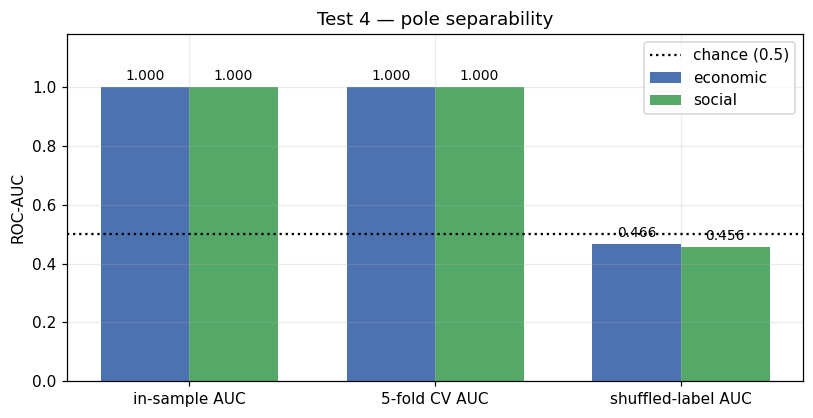

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.9))
labels = ["in-sample AUC", "5-fold CV AUC", "shuffled-label AUC"]
x = np.arange(3)
width = 0.36
for i, (axis, color) in enumerate([(economic, "#4C72B0"), (social, "#55A868")]):
    sep = tier1.held_out_separability(axis, kfolds=5, seed=0)
    vals = [sep["in_sample_auc"], sep["cross_validated_auc"], sep["shuffled_label_auc"]]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=axis.name, color=color)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.025, f"{v:.3f}",
                ha="center", fontsize=9)
ax.axhline(0.5, color="black", ls=":", label="chance (0.5)")
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.18)
ax.set_ylabel("ROC-AUC")
ax.set_title("Test 4 — pole separability")
ax.legend()
plt.tight_layout()
plt.show()

**Result — Pass.** The 5-fold cross-validated AUC is **1.000** on both axes, while the
shuffled-label floor sits at ~0.46 (chance). The direction perfectly separates held-out
contrastive pairs it was not built on — it *generalizes* rather than memorizing the seed
statements.

### Test 5 — Extraction-Method Agreement

The steering direction can be estimated two ways: the **mean-difference** of the pole
activations, or the weight vector of a **logistic-regression** probe trained to separate
the poles. If both estimators recover the same direction, the result is a property of
the model's representation rather than an artifact of one estimator.

We read back the per-layer cosine between the two methods' vectors.

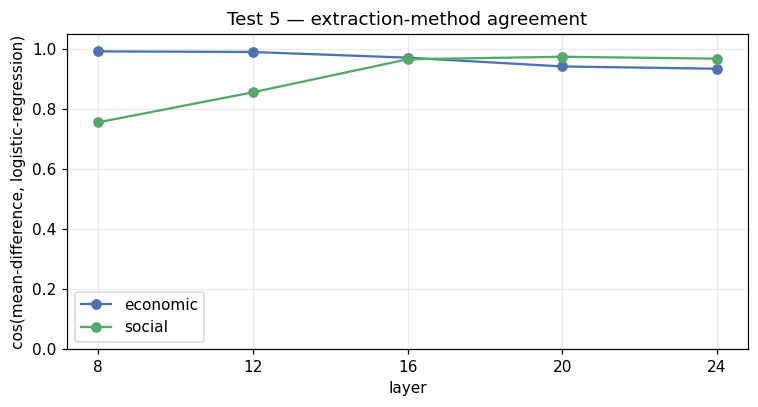

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.8))
for axis, color in [(economic, "#4C72B0"), (social, "#55A868")]:
    ag = tier1.method_agreement(axis, tier1.DEFAULT_VECTORS_DIR)
    method_cosine = [ag["method_cosine_per_layer"][l] for l in axis.layers]
    ax.plot([str(l) for l in axis.layers], method_cosine, "o-", color=color, label=axis.name)
ax.set_ylim(0, 1.05)
ax.set_xlabel("layer")
ax.set_ylabel("cos(mean-difference, logistic-regression)")
ax.set_title("Test 5 — extraction-method agreement")
ax.legend()
plt.tight_layout()
plt.show()

**Result — Pass.** The two extraction methods agree strongly (cosine 0.93–0.99) on the
economic axis and on the social axis at layers 16–24. The only loosening is the social
axis at layers 8 and 12 (0.76, 0.86) — but the aggregation already assigns those layers
only 5% / 7% weight, so the final vector is unaffected. The steering direction is a
property of the representation, not of the estimator.

## Tier 1 Verdict

| Test | Result | Notes |
|---|---|---|
| 1 — Orthogonality | **Pass** | axes share ~1.5% variance — genuinely 2D |
| 2 — Cross-projection | **Pass** | diagonal 5–7× off-diagonal; ~*d*=1 leakage flagged |
| 3 — Null baselines | **Pass** | real signal beats random & shuffled nulls, *p* = 0.002 |
| 4 — Held-out separability | **Pass** | 5-fold CV AUC = 1.000 vs. 0.46 chance floor |
| 5 — Extraction-method agreement | **Pass** | mean-difference and logistic-regression vectors agree |

**The steering vectors are 2-dimensional, non-artifactual, generalizing, and internally
consistent.** Tier 1 gives a green light to invest in the deeper tests.

**One caveat to carry forward (a Tier 3 candidate):** the cross-projection off-diagonal
leakage (~Cohen's *d* = 1) — social pairs move the economic axis and vice versa, possibly
a genuine ideological correlation rather than contamination.

### Next steps

- **Tier 2 — External ground truth.** Correlate corpus projections against *measured*
  ideology — DW-NOMINATE scores (the repo already has `hein_congressional.jsonl`), MARPOR
  manifesto RILE scores, and media-bias ratings.
- **Tier 3 — Robustness.** Negation flips, paraphrase invariance, and cross-topic
  generalization of the steering direction.